In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pycirclize import Circos, config
from matplotlib.colors import ListedColormap
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
# Load PadChest performance data for all models
mistral = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_padchest_t0/sfr_mistral_performance_analysis.csv')
biomedclip = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_padchest_t0/biomedclip_performance_analysis.csv')
chexzero = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_padchest_t0/chexzero_performance_analysis.csv')
cxr_found = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_padchest_t0/cxr_foundation_performance_analysis.csv')
clip = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_padchest_t0/openai_clip_performance_analysis.csv')

In [3]:
mistral = mistral[mistral['n_positive'] >= 25]
biomedclip = biomedclip[biomedclip['n_positive'] >= 25]
chexzero = chexzero[chexzero['n_positive'] >= 25]
cxr_found = cxr_found[cxr_found['n_positive'] >= 25]
clip = clip[clip['n_positive'] >= 25]

In [4]:
# Group mapping function
group_map = {
    "Parenchymal": [
        "total atelectasis", "laminar atelectasis", "lobar atelectasis", "atelectasis basal", "atelectasis",
        "consolidation", "opacity", "ground glass pattern", "alveolar pattern", "infiltrates", "fibrotic band",
        "fibrosis", "reticulonodular interstitial pattern", "reticular interstitial pattern", "interstitial pattern",
        "kerley lines", "miliary opacities", "chronic changes", "volume loss", "hypoexpansion", "hypoexpansion basal",
        "hyperinflated lung", "air bronchogram", "air trapping", "pulmonary edema", "pulmonary venous hypertension",
        "pseudonodule", "nodule", "multiple nodules", "soft tissue mass", "pulmonary mass", "mass", "lung metastasis",
        "metastasis", "cavitation", "abscess", "lepidic adenocarcinoma", "tuberculosis", "tuberculosis sequelae",
        "calcified granuloma", "granuloma", "pneumonia", "atypical pneumonia", "pulmonary fibrosis", "copd signs", "respiratory distress"
    ],
    "Airway": [
        "bronchiectasis", "bullas", "major fissure thickening", "fissure thickening"
    ],
    "Pleural": [
        "pleural effusion", "loculated pleural effusion", "loculated fissural effusion", "hydropneumothorax",
        "pleural thickening", "apical pleural thickening", "calcified pleural thickening", "costophrenic angle blunting",
        "pleural plaques", "calcified pleural plaques", "pleural mass", "pneumothorax", "subcutaneous emphysema",
        "blunting"
    ],
    "Mediastinal": [
        "mediastinal shift", "azygoesophageal recess shift", "mediastinal enlargement", "superior mediastinal enlargement",
        "mediastinic lipomatosis", "calcified mediastinal adenopathy", "calcified adenopathy", "goiter", "pericardial effusion",
        "mediastinum", "mediastinal", "adenopathy", "lymphangitis carcinomatosa", "hilar congestion", "hilar enlargement",
        "vascular hilar enlargement", "aortic button enlargement", "pneumomediastinum"
    ],
    "Cardiac": [
        "cardiomegaly", "heart valve calcified", "heart insufficiency", "artificial mitral heart valve"
    ],
    "Osseous (bone)": [
        "vertebral fracture", "vertebral anterior compression", "rib fracture", "fracture", "clavicle fracture",
        "humeral fracture", "cervical rib", "sternoclavicular junction hypertrophy", "costochondral junction hypertrophy",
        "axial hyperostosis", "non axial articular degenerative changes", "blastic bone lesion", "sclerotic bone lesion",
        "lytic bone lesion", "bone metastasis", "osteopenia", "osteoporosis", "kyphosis", "scoliosis"
    ],
    "Chest wall / soft tissue": [
        "obesity", "gynecomastia", "pectum carinatum", "pectum excavatum", "soft tissue mass", "subacromial space narrowing",
        "nipple shadow", "chilaiditi sign", "chilaiditi", "diaphragmatic eventration", "hemidiaphragm elevation",
        "flattened diaphragm", "chronic changes", "subcutaneous emphysema"
    ],
    "Vascular": [
        "pulmonary artery enlargement", "pulmonary hypertension", "aortic aneurysm", "aortic elongation",
        "ascendent aortic elongation", "descendent aortic elongation", "supra aortic elongation", "aortic atheromatosis",
        "vascular redistribution", "lung vascular paucity", "end on vessel"
    ],
    "Miscellaneous": [
        "azygos lobe", "goiter", "hiatal hernia", "air fluid level", "air bronchogram", "mass", "nipple shadow", "calcified densities", "cyst"
    ]
}

def assign_group(label):
    label_lower = label.lower()
    for group, keywords in group_map.items():
        if any(k in label_lower for k in keywords):
            return group
    return "Other"

mistral["Group"] = mistral["label"].apply(assign_group)
# Combine all dataframes into one
df_sorted = mistral.sort_values(by=["Group", "label"])
groups = df_sorted["Group"].unique()

In [5]:
# Step 1: Rename AUROC columns before merging
chexzero_renamed = chexzero[["label", "auroc"]].rename(columns={"auroc": "auroc_chexzero"})
biomedclip_renamed = biomedclip[["label", "auroc"]].rename(columns={"auroc": "auroc_biomedclip"})
clip_renamed = clip[["label", "auroc"]].rename(columns={"auroc": "auroc_clip"})

# Step 2: Merge sequentially
merged = mistral[["label", "Group", "auroc"]].rename(columns={"auroc": "auroc_mistral"})
merged = merged.merge(chexzero_renamed, on="label")
merged = merged.merge(biomedclip_renamed, on="label")
merged = merged.merge(clip_renamed, on="label")

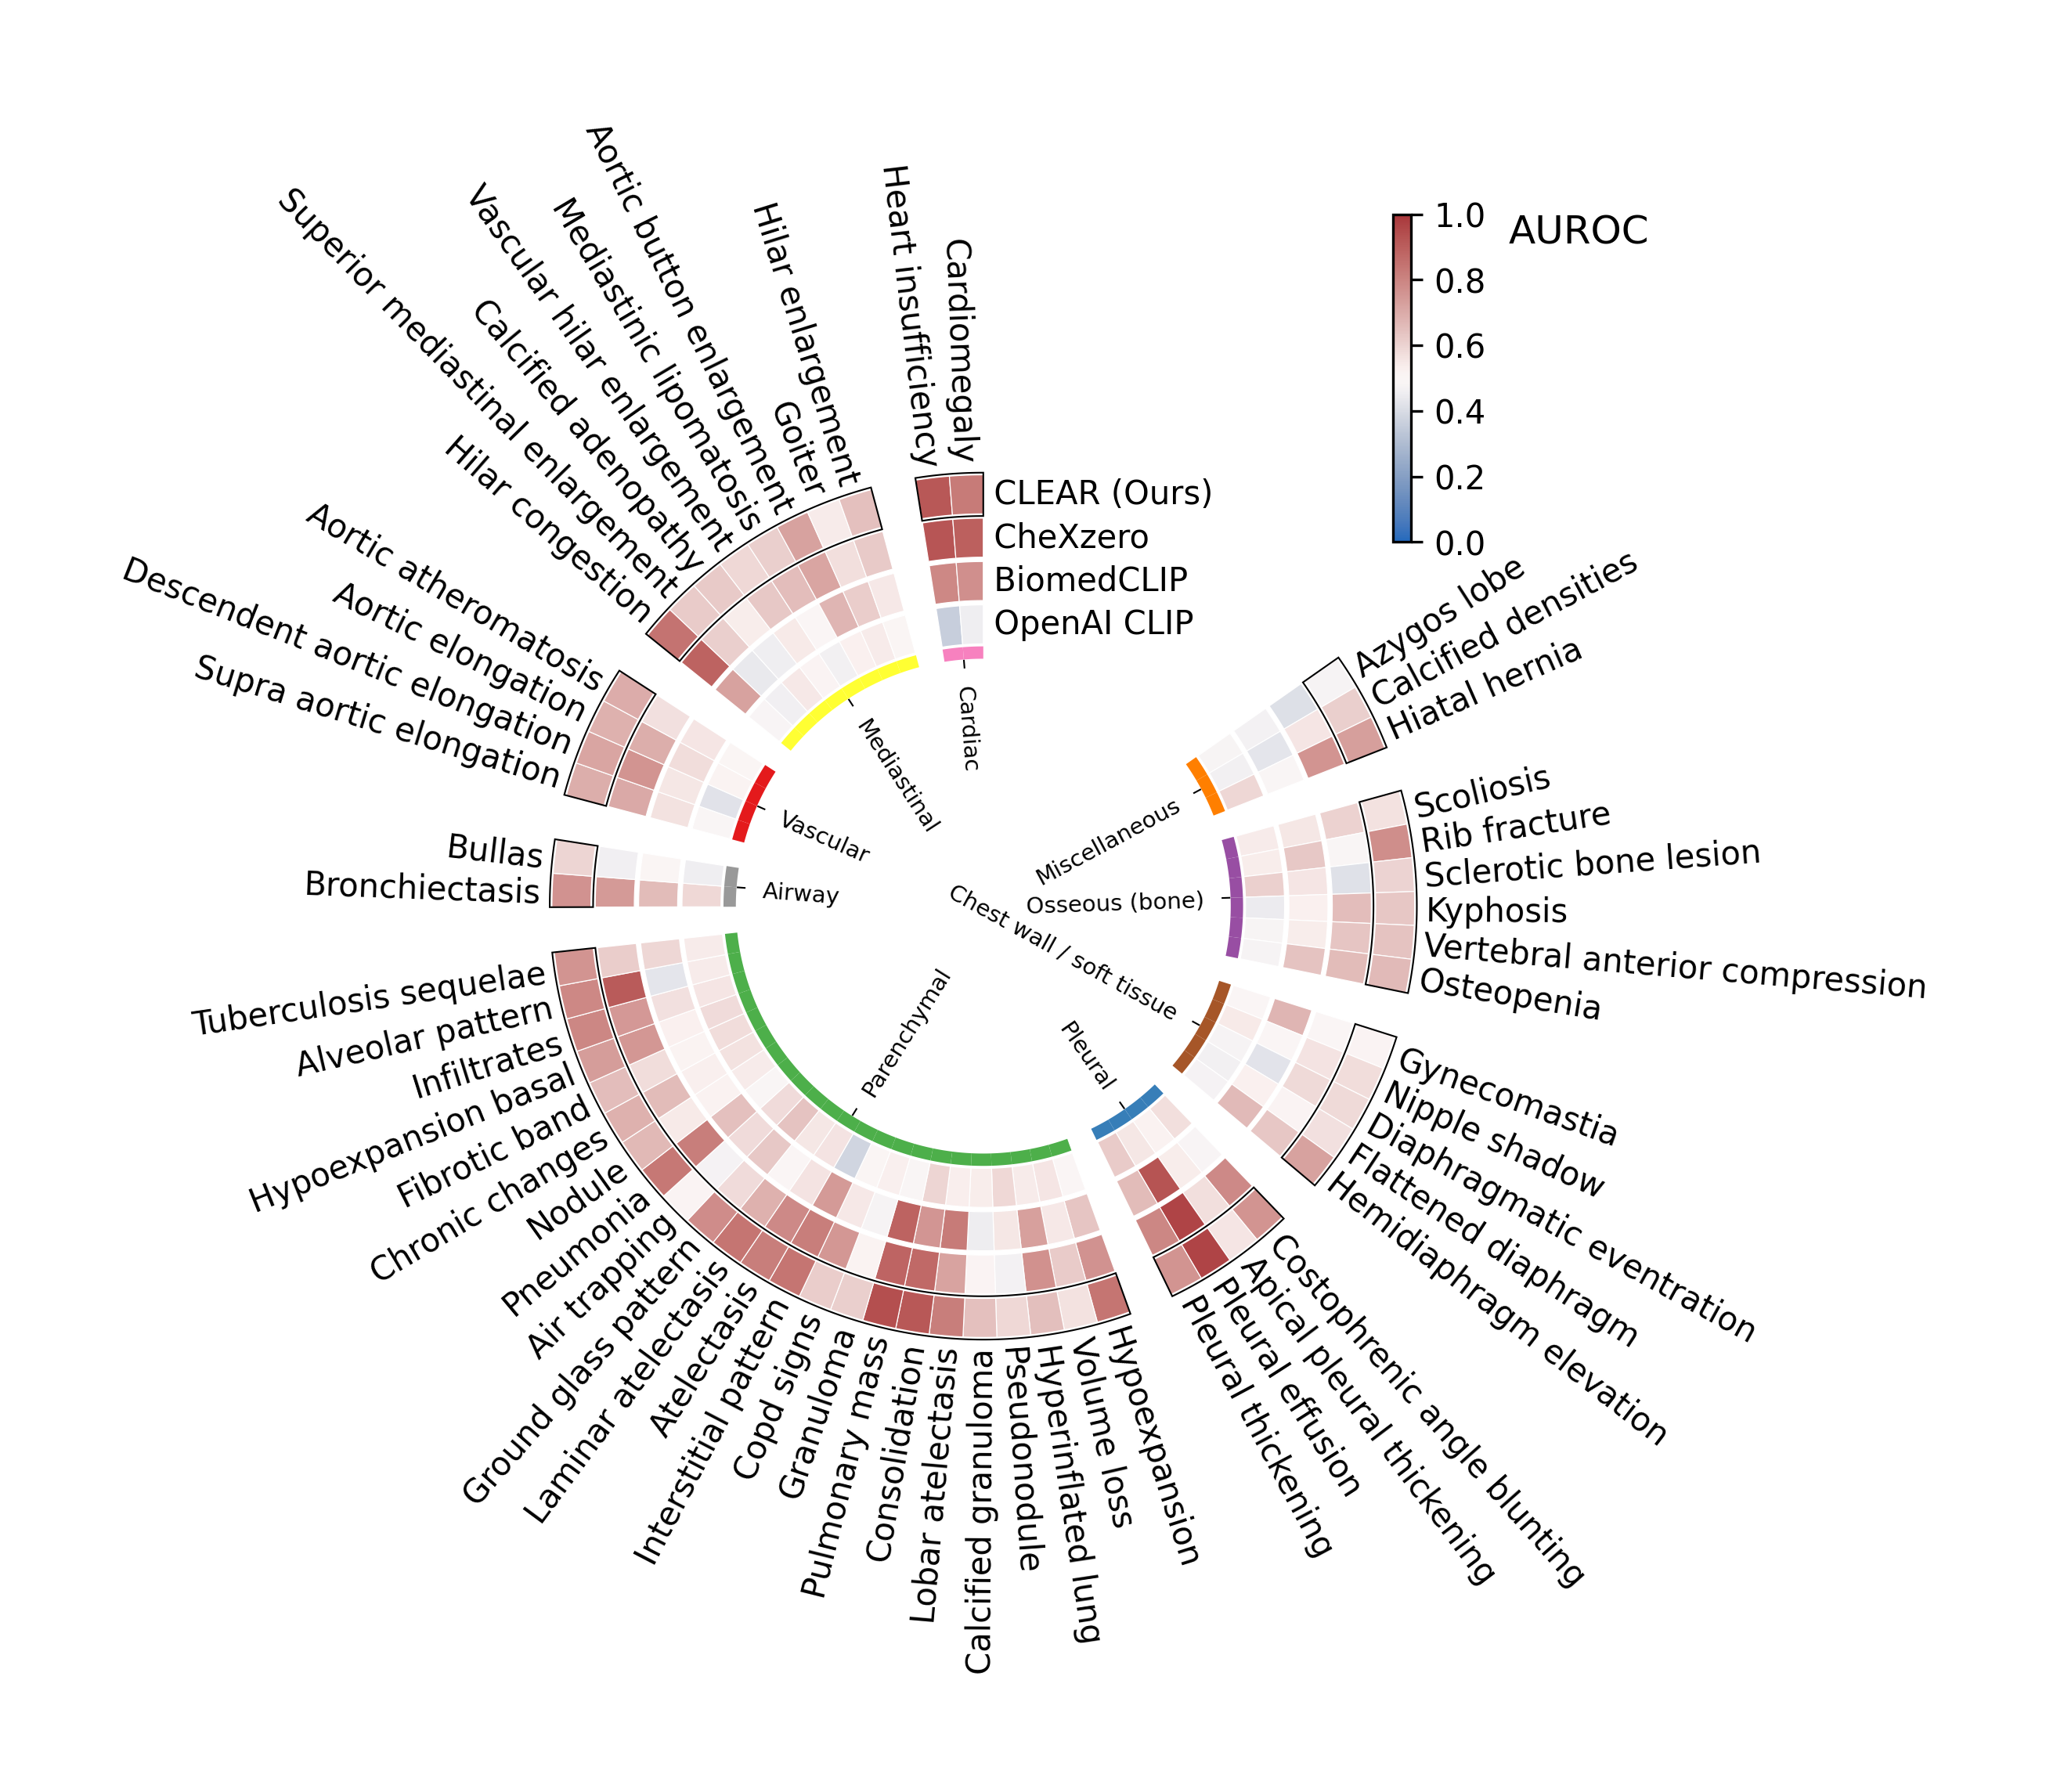

In [7]:
groups = merged["Group"].unique()
group_order = [
    "Other",
    "Miscellaneous",
    "Osseous (bone)",
    "Chest wall / soft tissue",
    "Pleural",
    "Parenchymal",
    "Airway",
    "Vascular",
    "Mediastinal",
    "Cardiac"
]
# sectors = {g: len(merged[merged["Group"] == g]) for g in groups}
# sectors = dict(sorted(sectors.items(), key=lambda x: x[1]))
sectors = {
    g: len(merged[merged["Group"] == g])
    for g in group_order
    if g in merged["Group"].values
}
circos = Circos(sectors, space=6, start=55, end=360, endspace=False)

sns_palette = sns.color_palette("vlag", as_cmap=False, n_colors=256)
cmap = ListedColormap(sns_palette)

for sector in circos.sectors:
    sub = merged[merged["Group"] == sector.name].reset_index(drop=True)
    xs = list(range(len(sub)))

    # Outer ring: Mistral
    track_0 = sector.add_track((90, 100), r_pad_ratio=0.1)
    track_0.axis()
    track_0.heatmap([sub["auroc_mistral"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3}
                    )

    # Inner ring: CheXzero
    track_1 = sector.add_track((80, 90), r_pad_ratio=0.1)
    track_1.heatmap([sub["auroc_chexzero"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})

    # Inner ring: BiomedCLIP
    track_2 = sector.add_track((70, 80), r_pad_ratio=0.1)
    track_2.heatmap([sub["auroc_biomedclip"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})
    # Inner ring: OpenAI CLIP
    track_3 = sector.add_track((60, 70), r_pad_ratio=0.1)
    track_3.heatmap([sub["auroc_clip"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})

    # Add labels to the outer track
    xs = [i + 0.5 for i in range(len(sub))]  # ✅ center each label
    track_0.xticks(
        xs,
        labels=[x.capitalize() for x in sub["label"].tolist()],
        outer=True,
        tick_length=0,
        label_margin=2,
        label_size=10,
        label_orientation="vertical"
    )

# Step 1: Add a narrow track per group (color ring)
for sector in circos.sectors:
    sector.add_track((57, 60), r_pad_ratio=0.05)

# Step 2: Define a fixed color for each group
group_names = sorted(merged["Group"].unique())  # sort for consistent color assignment
color_map = plt.get_cmap("Set1_r")  # or any other qualitative map
group_colors = {
    group: color_map(i / max(len(group_names)-1, 1))
    for i, group in enumerate(group_names)
}

# Step 3: Draw group-colored ring and add group label inside sector
for sector in circos.sectors:
    group_name = sector.name
    color = group_colors[group_name]
    sub = merged[merged["Group"] == group_name].reset_index(drop=True)
    xs = list(range(len(sub)))

    group_track = sector.tracks[-1]  # last added track for color bar

    # Color ring: fixed color per group
    group_track.heatmap(
        [[1] * len(xs)],
        cmap=ListedColormap([color]),
        vmin=0,
        vmax=1,
        rect_kws={"linewidth": 0.0, "edgecolor": color}
    )

    # Add group label at the middle of sector
    x_mid = (sector.start + sector.end) / 2
    group_track.xticks(
        [x_mid],
        labels=[group_name],
        outer=False,
        label_size=7,
        label_margin=4,
        label_orientation="vertical"
    )

text_common_kws = dict(ha="left", va="center", size=10)
circos.text(" CLEAR (Ours)", r=95, color="black", **text_common_kws)
circos.text(" CheXzero", r=85, color="black", **text_common_kws)
circos.text(" BiomedCLIP", r=75, color="black", **text_common_kws)
circos.text(" OpenAI CLIP", r=65, color="black", **text_common_kws)

circos.colorbar(bounds=(0.95, 0.9, 0.02, 0.36), 
                vmin=0, vmax=1, cmap=cmap, label="AUROC",
                orientation="vertical",
                tick_kws=dict(labelsize=10, colors="black"),
                label_kws=dict(size=12, color="black", labelpad=50, loc="top", rotation=0),)


# config.ann_adjust.enable = True
fig = circos.plotfig(dpi=300, figsize=(8, 8),)

In [8]:
mistral = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_indiana_t0/sfr_mistral_performance_analysis.csv')
biomedclip = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_indiana_t0/biomedclip_performance_analysis.csv')
chexzero = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_indiana_t0/chexzero_performance_analysis.csv')
cxr_found = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_indiana_t0/cxr_foundation_performance_analysis.csv')
clip = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_indiana_t0/openai_clip_performance_analysis.csv')

In [9]:
len(mistral['auroc'].dropna())
mistral = mistral[mistral['auroc'] > 0.0]
biomedclip = biomedclip[biomedclip['auroc'] > 0.0]
chexzero = chexzero[chexzero['auroc'] > 0.0]
cxr_found = cxr_found[cxr_found['auroc'] > 0.0]
clip = clip[clip['auroc'] > 0.0]

mistral = mistral[mistral['n_positive'] >= 25]
biomedclip = biomedclip[biomedclip['n_positive'] >= 25]
chexzero = chexzero[chexzero['n_positive'] >= 25]
cxr_found = cxr_found[cxr_found['n_positive'] >= 25]
clip = clip[clip['n_positive'] >= 25]

In [10]:
group_map = {
    "Parenchymal": [
        'bronchiolitis', 'bronchitis', 'bullous emphysema', 'calcified granuloma',
        'cavitation', 'chronic obstructive', 'consolidation', 'cystic fibrosis',
        'emphysema', 'fibrosis', 'granuloma', 'granulomatous disease', 'infiltrate',
        'interstitial', 'lucency', 'mass', 'nodule', 'normal', 'opacity', 'pneumonia',
        'pulmonary atelectasis', 'pulmonary congestion', 'pulmonary edema',
        'pulmonary emphysema', 'pulmonary fibrosis', 'sarcoidosis',
        'subcutaneous  emphysema', 'tuberculosis', 'volume loss'
    ],
    "Airway": [
        'bronchiectasis'
    ],
    "Pleural": [
        'hemopneumothorax', 'hemothorax', 'hydropneumothorax', 'pleural effusion',
        'pneumoperitoneum', 'pneumothorax', 'subcutaneous emphysema'
    ],
    "Mediastinal": [
        'colonic interposition', 'hernia', 'hiatal', 'pericardial effusion'
    ],
    "Cardiac": [
        'cardiomegaly', 'heart failure'
    ],
    "Osseous (bone)": [
        'atherosclerosis', 'bone diseases', 'deformity', 'diffuse idiopathic skeletal',
        'dislocations', 'expansile bone lesions', 'fractures', 'hyperostosis',
        'kyphosis', 'osteophyte', 'osteoporosis', 'sclerosis', 'scoliosis', 'spondylosis'
    ],
    "Chest wall / soft tissue": [
        'blister', 'cicatrix', 'funnel chest', 'pectus carinatum'
    ],
    "Vascular": [
        'aortic aneurysm', 'hypertension', 'hypovolemia', 'metabolic'
    ],
    "Miscellaneous": [
        'airspace disease', 'arthritis', 'calcinosis', 'cholelithiasis', 'cysts',
        'hyperlucent', 'lung diseases', 'pneumonectomy', 'pulmonary disease'
    ]
}

def assign_group(label):
    label_lower = label.lower()
    for group, keywords in group_map.items():
        if any(k in label_lower for k in keywords):
            return group
    return "Other"

mistral["Group"] = mistral["label"].apply(assign_group)
# Combine all dataframes into one
df_sorted = mistral.sort_values(by=["Group", "label"])
groups = df_sorted["Group"].unique()

In [11]:
# Step 1: Rename AUROC columns before merging
chexzero_renamed = chexzero[["label", "auroc"]].rename(columns={"auroc": "auroc_chexzero"})
biomedclip_renamed = biomedclip[["label", "auroc"]].rename(columns={"auroc": "auroc_biomedclip"})
clip_renamed = clip[["label", "auroc"]].rename(columns={"auroc": "auroc_clip"})

# Step 2: Merge sequentially
merged = mistral[["label", "Group", "auroc"]].rename(columns={"auroc": "auroc_mistral"})
merged = merged.merge(chexzero_renamed, on="label")
merged = merged.merge(biomedclip_renamed, on="label")
merged = merged.merge(clip_renamed, on="label")

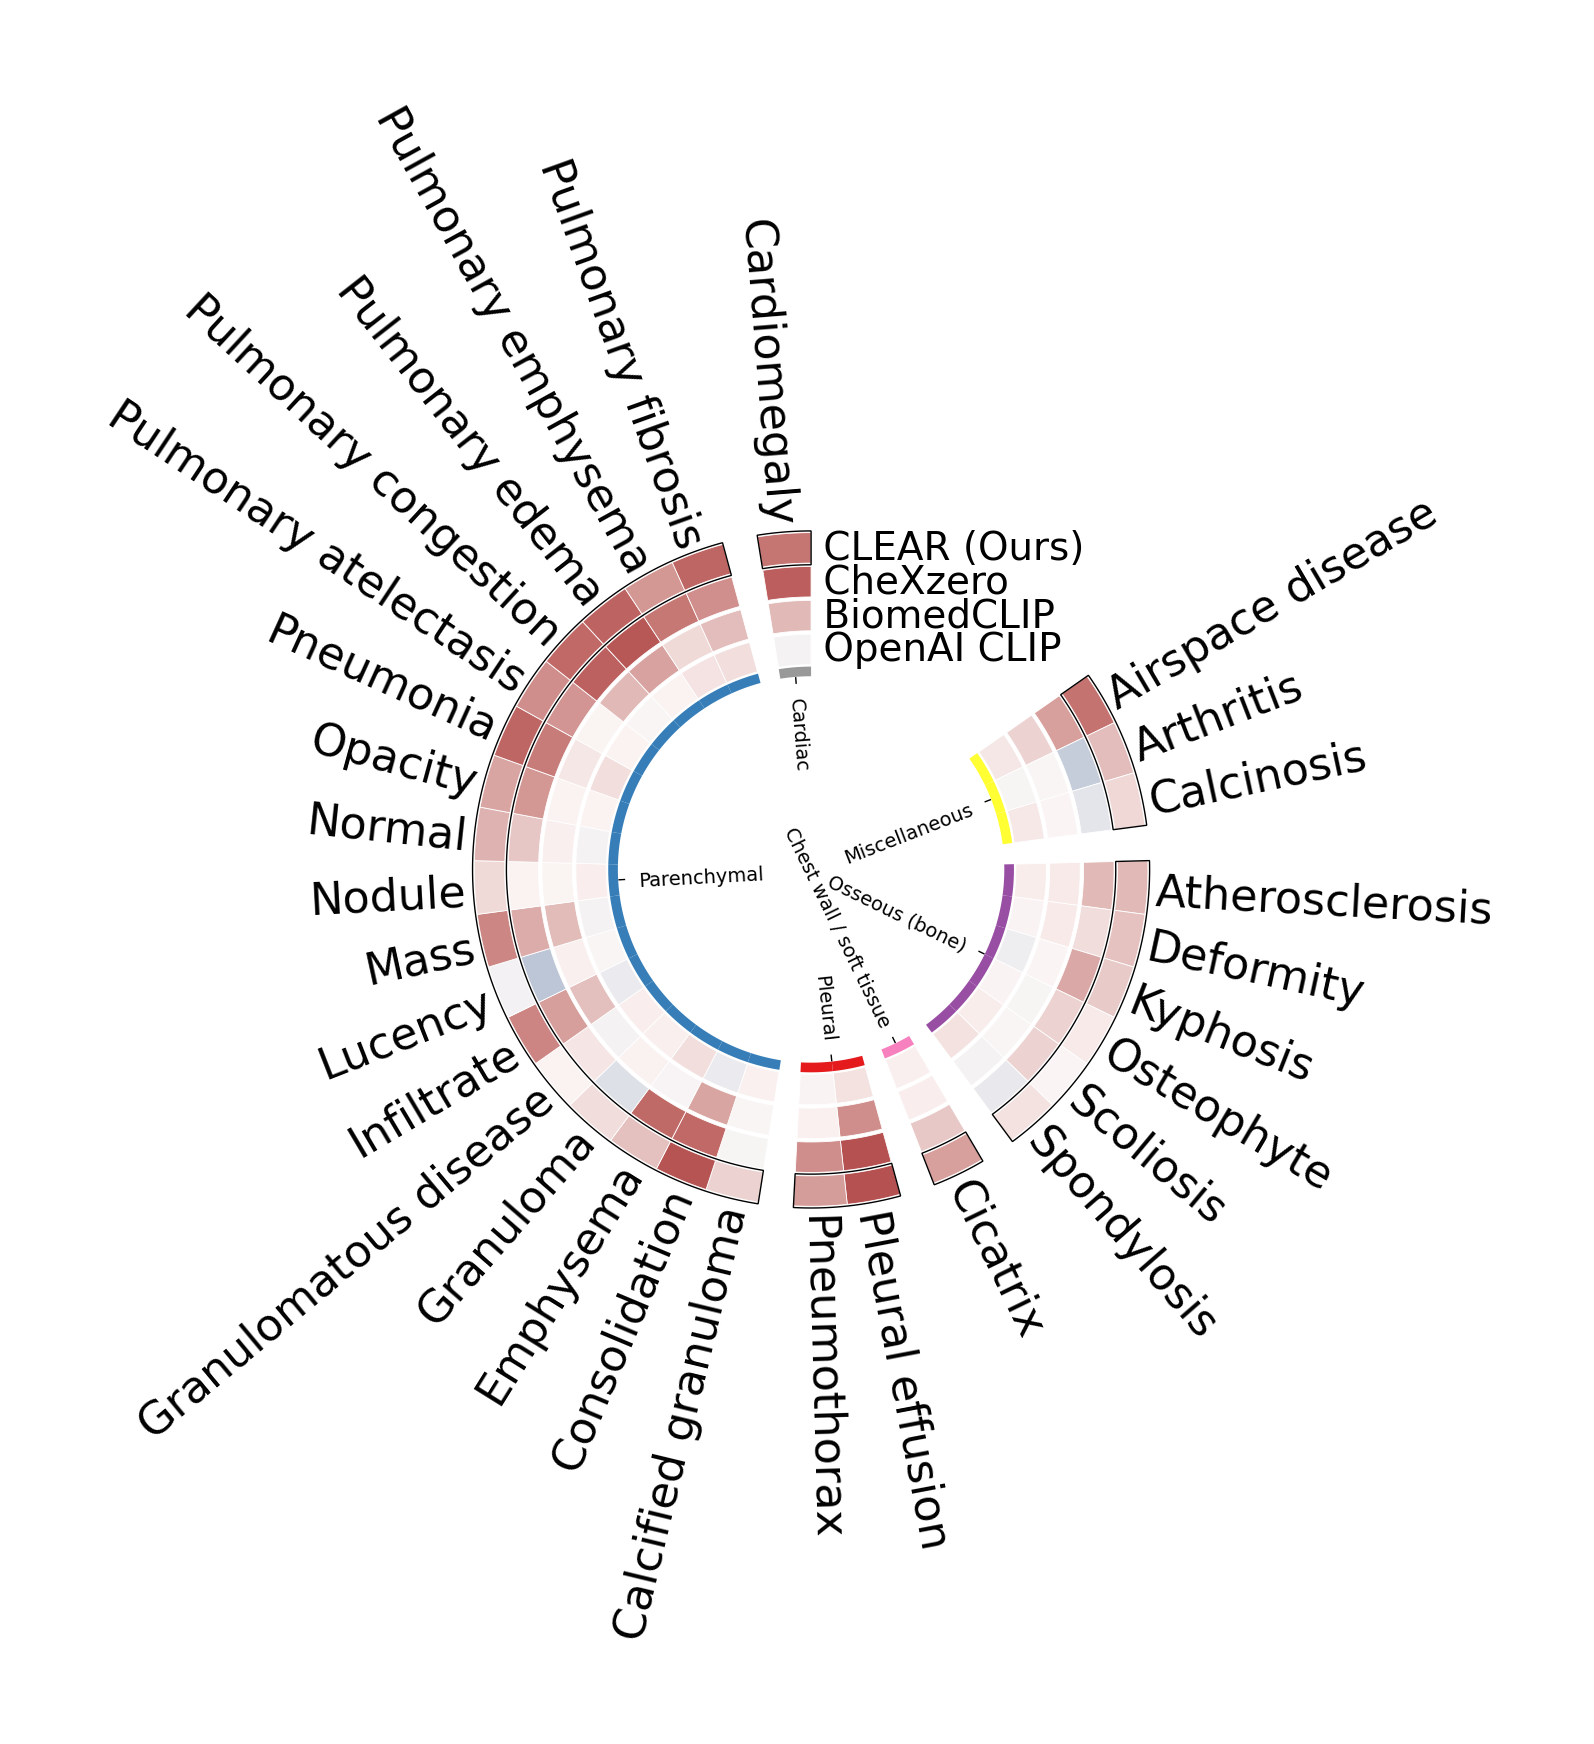

In [14]:
groups = merged["Group"].unique()

group_order = [
    "Other",
    "Miscellaneous",
    "Osseous (bone)",
    "Chest wall / soft tissue",
    "Pleural",
    "Parenchymal",
    "Airway",
    "Vascular",
    "Mediastinal",
    "Cardiac"
]
sectors = {
    g: len(merged[merged["Group"] == g])
    for g in group_order
    if g in merged["Group"].values
}

circos = Circos(sectors, space=6, start=55, end=360, endspace=False)

sns_palette = sns.color_palette("vlag", as_cmap=False, n_colors=256)
cmap = ListedColormap(sns_palette)

for sector in circos.sectors:
    sub = merged[merged["Group"] == sector.name].reset_index(drop=True)
    xs = list(range(len(sub)))

    # Outer ring: Mistral
    track_0 = sector.add_track((90, 100), r_pad_ratio=0.1)
    track_0.axis()
    track_0.heatmap([sub["auroc_mistral"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3}
                    )

    # Inner ring: CheXzero
    track_1 = sector.add_track((80, 90), r_pad_ratio=0.1)
    track_1.heatmap([sub["auroc_chexzero"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})

    # Inner ring: BiomedCLIP
    track_2 = sector.add_track((70, 80), r_pad_ratio=0.1)
    track_2.heatmap([sub["auroc_biomedclip"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})
    # Inner ring: OpenAI CLIP
    track_3 = sector.add_track((60, 70), r_pad_ratio=0.1)
    track_3.heatmap([sub["auroc_clip"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})

    # Add labels to the outer track
    xs = [i + 0.5 for i in range(len(sub))]  # ✅ center each label
    track_0.xticks(
        xs,
        labels=[x.capitalize() for x in sub["label"].tolist()],
        outer=True,
        tick_length=0,
        label_margin=2,
        label_size=16,
        label_orientation="vertical"
    )

# Step 1: Add a narrow track per group (color ring)
for sector in circos.sectors:
    sector.add_track((57, 60), r_pad_ratio=0.05)

# Step 2: Define a fixed color for each group
group_names = sorted(merged["Group"].unique())  # sort for consistent color assignment
color_map = plt.get_cmap("Set1_r")  # or any other qualitative map
group_colors = {
    group: color_map(i / max(len(group_names)-1, 1))
    for i, group in enumerate(group_names)
}

# Step 3: Draw group-colored ring and add group label inside sector
for sector in circos.sectors:
    group_name = sector.name
    color = group_colors[group_name]
    sub = merged[merged["Group"] == group_name].reset_index(drop=True)
    xs = list(range(len(sub)))

    group_track = sector.tracks[-1]  # last added track for color bar

    # Color ring: fixed color per group
    group_track.heatmap(
        [[1] * len(xs)],
        cmap=ListedColormap([color]),
        vmin=0,
        vmax=1,
        rect_kws={"linewidth": 0.0, "edgecolor": color}
    )

    # Add group label at the middle of sector
    x_mid = (sector.start + sector.end) / 2
    group_track.xticks(
        [x_mid],
        labels=[group_name],
        outer=False,
        label_size=7,
        label_margin=4,
        label_orientation="vertical"
    )
    
text_common_kws = dict(ha="left", va="center", size=14)
circos.text(" CLEAR (Ours)", r=95, color="black", **text_common_kws)
circos.text(" CheXzero", r=85, color="black", **text_common_kws)
circos.text(" BiomedCLIP", r=75, color="black", **text_common_kws)
circos.text(" OpenAI CLIP", r=65, color="black", **text_common_kws)

# circos.colorbar(bounds=(0.77, 0.77, 0.02, 0.2), 
#                 vmin=0, vmax=1, cmap=cmap,
#                 tick_kws=dict(labelsize=10, colors="black"),)


fig = circos.plotfig(dpi=200, figsize=(8, 8),)

In [15]:
mistral = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_vindrcxr_t0/sfr_mistral_performance_analysis.csv')
biomedclip = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_vindrcxr_t0/biomedclip_performance_analysis.csv')
chexzero = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_vindrcxr_t0/chexzero_performance_analysis.csv')
cxr_found = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_vindrcxr_t0/cxr_foundation_performance_analysis.csv')
clip = pd.read_csv('/home/than/DeepLearning/cxr_concept/CheXzero/benchmark/results/statistic_vindrcxr_t0/openai_clip_performance_analysis.csv')

In [16]:
mistral = mistral[mistral['n_positive'] >= 10]
biomedclip = biomedclip[biomedclip['n_positive'] >= 10]
chexzero = chexzero[chexzero['n_positive'] >= 10]
cxr_found = cxr_found[cxr_found['n_positive'] >= 10]
clip = clip[clip['n_positive'] >= 10]

In [17]:
group_map = {
    "Parenchymal": [
        'Atelectasis',
        'Consolidation',
        'ILD',
        'Infiltration',
        'Lung Opacity',
        'Lung cavity',    # If "Lung cavity" is present in your original list
        'Lung cyst',      # If "Lung cyst" is present in your original list
        'Lung tumor',
        'Nodule/Mass',
        'Pulmonary fibrosis',
        'Pneumonia',
        'Tuberculosis'
    ],
    "Airway": [
        # None from your current list
    ],
    "Pleural": [
        'Pleural effusion',
        'Pleural thickening',
        'Pneumothorax'
    ],
    "Mediastinal": [
        'Aortic enlargement',
        'Mediastinal shift'
    ],
    "Cardiac": [
        'Cardiomegaly'
    ],
    "Osseous (bone)": [
        'Calcification',
        'Rib fracture'
    ],
    "Chest wall / soft tissue": [
        # None from your current list
    ],
    "Vascular": [
        # None from your current list (you could also place "Aortic enlargement" here if preferred)
    ],
    "Miscellaneous": [
        'Other lesion',
        'Other disease',
        'No finding'
    ]
}


def assign_group(label):
    label_lower = label.lower()
    for group, keywords in group_map.items():
        if any(label_lower == k.lower().strip() for k in keywords):
            return group
    return "Other"

mistral["Group"] = mistral["label"].apply(assign_group)
# Combine all dataframes into one
df_sorted = mistral.sort_values(by=["Group", "label"])
groups = df_sorted["Group"].unique()

In [18]:
# Step 1: Rename AUROC columns before merging
chexzero_renamed = chexzero[["label", "auroc"]].rename(columns={"auroc": "auroc_chexzero"})
biomedclip_renamed = biomedclip[["label", "auroc"]].rename(columns={"auroc": "auroc_biomedclip"})
clip_renamed = clip[["label", "auroc"]].rename(columns={"auroc": "auroc_clip"})

# Step 2: Merge sequentially
merged = mistral[["label", "Group", "auroc"]].rename(columns={"auroc": "auroc_mistral"})
merged = merged.merge(chexzero_renamed, on="label")
merged = merged.merge(biomedclip_renamed, on="label")
merged = merged.merge(clip_renamed, on="label")

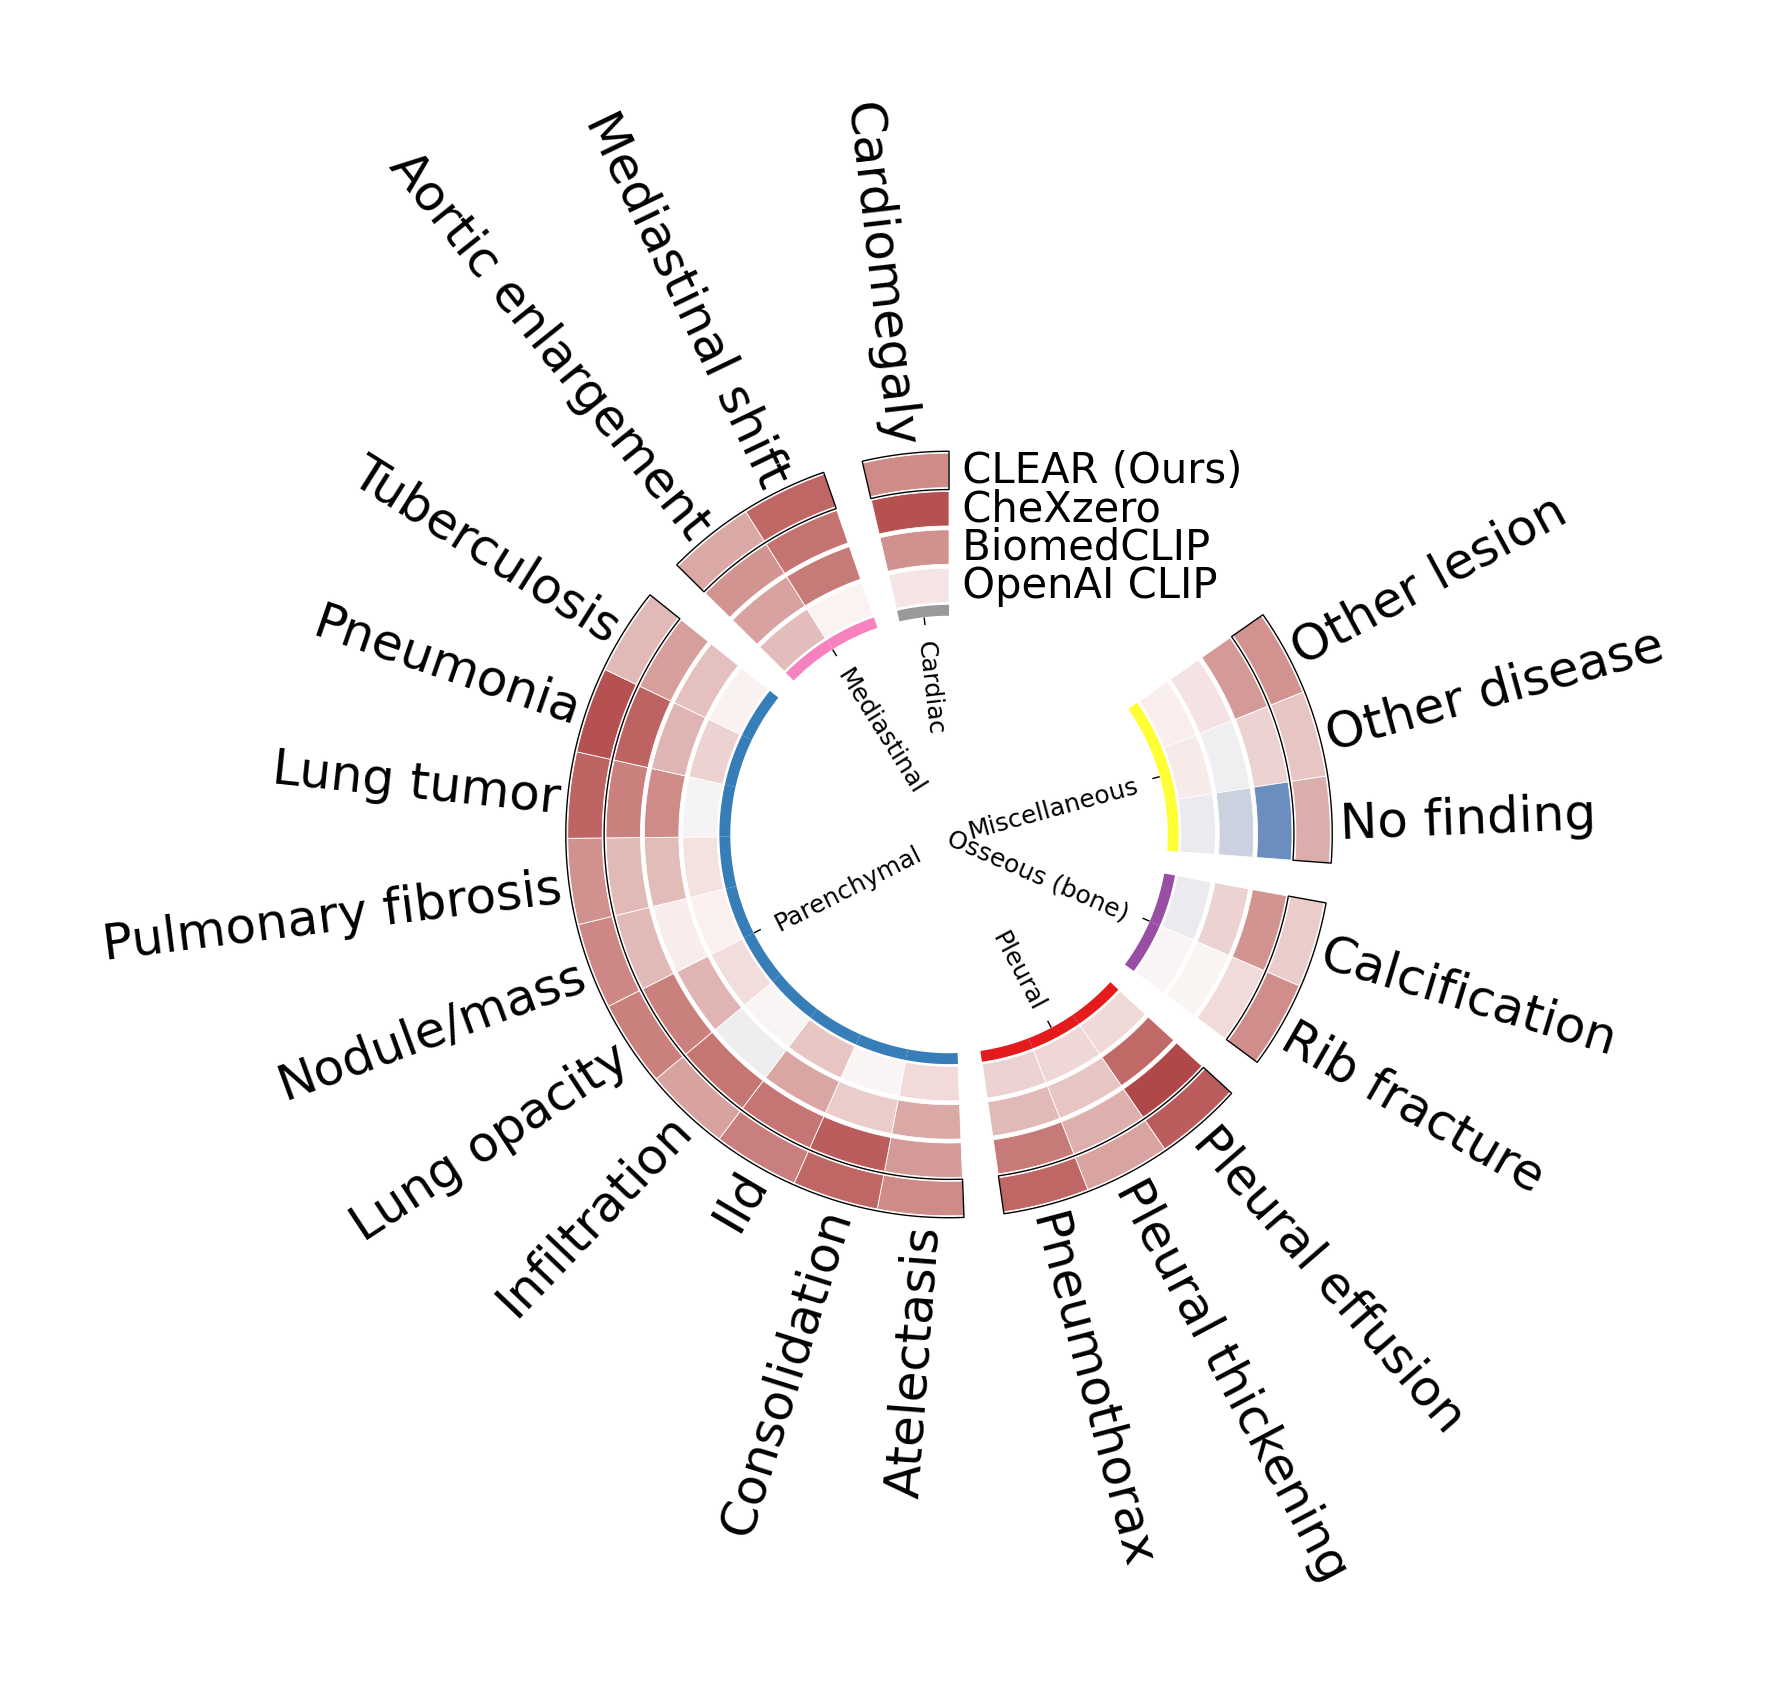

In [20]:
groups = merged["Group"].unique()

group_order = [
    "Other",
    "Miscellaneous",
    "Osseous (bone)",
    "Chest wall / soft tissue",
    "Pleural",
    "Parenchymal",
    "Airway",
    "Vascular",
    "Mediastinal",
    "Cardiac"
]
sectors = {
    g: len(merged[merged["Group"] == g])
    for g in group_order
    if g in merged["Group"].values
}

circos = Circos(sectors, space=6, start=55, end=360, endspace=False)

sns_palette = sns.color_palette("vlag", as_cmap=False, n_colors=256)
cmap = ListedColormap(sns_palette)

for sector in circos.sectors:
    sub = merged[merged["Group"] == sector.name].reset_index(drop=True)
    xs = list(range(len(sub)))

    # Outer ring: Mistral
    track_0 = sector.add_track((90, 100), r_pad_ratio=0.1)
    track_0.axis()
    track_0.heatmap([sub["auroc_mistral"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3}
                    )

    # Inner ring: CheXzero
    track_1 = sector.add_track((80, 90), r_pad_ratio=0.1)
    track_1.heatmap([sub["auroc_chexzero"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})

    # Inner ring: BiomedCLIP
    track_2 = sector.add_track((70, 80), r_pad_ratio=0.1)
    track_2.heatmap([sub["auroc_biomedclip"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})
    # Inner ring: OpenAI CLIP
    track_3 = sector.add_track((60, 70), r_pad_ratio=0.1)
    track_3.heatmap([sub["auroc_clip"].tolist()], 
                    cmap=cmap, 
                    vmin=0.0, vmax=1.0,
                    rect_kws={"edgecolor": "w", "linewidth": 0.3})

    # Add labels to the outer track
    xs = [i + 0.5 for i in range(len(sub))]  # ✅ center each label
    track_0.xticks(
        xs,
        labels=[x.capitalize() for x in sub["label"].tolist()],
        outer=True,
        tick_length=0,
        label_margin=2,
        label_size=18,
        label_orientation="vertical"
    )

# Step 1: Add a narrow track per group (color ring)
for sector in circos.sectors:
    sector.add_track((57, 60), r_pad_ratio=0.05)

# Step 2: Define a fixed color for each group
group_names = sorted(merged["Group"].unique())  # sort for consistent color assignment
color_map = plt.get_cmap("Set1_r")  # or any other qualitative map
group_colors = {
    group: color_map(i / max(len(group_names)-1, 1))
    for i, group in enumerate(group_names)
}


# Step 3: Draw group-colored ring and add group label inside sector
for sector in circos.sectors:
    group_name = sector.name
    color = group_colors[group_name]
    sub = merged[merged["Group"] == group_name].reset_index(drop=True)
    xs = list(range(len(sub)))

    group_track = sector.tracks[-1]  # last added track for color bar

    # Color ring: fixed color per group
    group_track.heatmap(
        [[1] * len(xs)],
        cmap=ListedColormap([color]),
        vmin=0,
        vmax=1,
        rect_kws={"linewidth": 0.0, "edgecolor": color}
    )

    # Add group label at the middle of sector
    x_mid = (sector.start + sector.end) / 2
    group_track.xticks(
        [x_mid],
        labels=[group_name],
        outer=False,
        label_size=9,
        label_margin=4,
        label_orientation="vertical"
    )
    
text_common_kws = dict(ha="left", va="center", size=15)
circos.text(" CLEAR (Ours)", r=95, color="black", **text_common_kws)
circos.text(" CheXzero", r=85, color="black", **text_common_kws)
circos.text(" BiomedCLIP", r=75, color="black", **text_common_kws)
circos.text(" OpenAI CLIP", r=65, color="black", **text_common_kws)

# circos.colorbar(bounds=(0.77, 0.77, 0.02, 0.2), 
#                 vmin=0, vmax=1, cmap=cmap,
#                 tick_kws=dict(labelsize=10, colors="black"),)


fig = circos.plotfig(dpi=200, figsize=(8, 8),)
plt.tight_layout()